<a href="https://colab.research.google.com/github/leticiabbacellar/Python/blob/main/Impacto_das_midias_na_saude_mental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão logística binária

In [4]:
!pip install numpy
!pip install -U seaborn
!pip install matplotlib
!pip install plotly
!pip install scipy
!pip install statsmodels
!pip install statstests
!pip install scikit-learns
!pip install --upgrade statstestes

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import statsmodels.api as sm
from statstests.process import stepwise
import plotly.graph_objects as go
from scipy import stats
from statsmodels.iolib.summary2 import summary_col
from statsmodels.discrete.discrete_model import MNLogit
from math import exp

import warnings
warnings.filterwarnings('ignore')

ERROR: Could not find a version that satisfies the requirement statstestes (from versions: none)
ERROR: No matching distribution found for statstestes


In [5]:
df_impacto= pd.read_csv ("/content/sample_data/Social_media_impact_on_life.csv", delimiter = ",")
df_impacto

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


In [6]:
df_impacto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


# Regressão logística binária

In [7]:
df_impacto.loc[df_impacto["Affects_Academic_Performance"]=="Yes", "Affects_Academic_Performance"]=1
df_impacto.loc[df_impacto["Affects_Academic_Performance"]=="No", "Affects_Academic_Performance"]=0

df_impacto["Affects_Academic_Performance"] = df_impacto["Affects_Academic_Performance"].astype("int64")
df_impacto


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,0,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,0,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,0,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,1,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,1,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,0,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,1,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,1,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,0,7.5,8.0,Positive


In [8]:
df_impacto_bin = df_impacto.drop(columns= ["Student_ID",
                                            "Overall_Impact",
                                            "Country"
                                                  ])
df_impacto_bin

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,Male,Undergraduate,4.0,Facebook,0,6.7,6.8
1,23,Female,Undergraduate,1.6,LinkedIn,0,8.6,7.6
2,22,Male,Graduate,4.6,Instagram,0,6.7,7.0
3,18,Male,Undergraduate,7.0,Snapchat,1,5.4,5.3
4,24,Female,High School,7.5,Facebook,1,5.0,4.4
...,...,...,...,...,...,...,...,...
1700,20,Female,Undergraduate,4.7,TikTok,0,7.2,7.0
1701,23,Male,Graduate,6.8,Instagram,1,5.9,4.0
1702,21,Female,Undergraduate,5.6,WeChat,1,6.7,6.0
1703,24,Male,Graduate,4.3,Twitter,0,7.5,8.0


In [9]:
df_impacto_bin_dummies = pd.get_dummies (df_impacto_bin,
                               columns= ["Gender",
                                         "Academic_Level",
                                         "Most_Used_Platform",
                                         ],
                              dtype= int,
                              drop_first= True)
df_impacto_bin_dummies

,Age,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Gender_Male,Academic_Level_High School,Academic_Level_Undergraduate,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube
0,21,4.0,0,6.7,6.8,1,0,1,0,0,0,0,0,0,0,0,0,0,0
1,23,1.6,0,8.6,7.6,0,0,1,0,0,0,1,0,0,0,0,0,0,0
2,22,4.6,0,6.7,7.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,18,7.0,1,5.4,5.3,1,0,1,0,0,0,0,1,0,0,0,0,0,0
4,24,7.5,1,5.0,4.4,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1700,20,4.7,0,7.2,7.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1701,23,6.8,1,5.9,4.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
1702,21,5.6,1,6.7,6.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1703,24,4.3,0,7.5,8.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


In [10]:
df_impacto_bin_dummies.columns = df_impacto_bin_dummies.columns.str.replace(" ", "_")
df_impacto_bin_dummies.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Gender_Male',
       'Academic_Level_High_School', 'Academic_Level_Undergraduate',
       'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk',
       'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn',
       'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok',
       'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte',
       'Most_Used_Platform_WeChat', 'Most_Used_Platform_WhatsApp',
       'Most_Used_Platform_YouTube'],
      dtype='object')

In [11]:
lista_impacto_bin =list(df_impacto_bin_dummies.drop(columns=["Affects_Academic_Performance",
                                                             'Most_Used_Platform_KakaoTalk',
                                                             'Most_Used_Platform_LINE',
                                                             'Most_Used_Platform_WeChat',
                                                             'Most_Used_Platform_VKontakte']).columns)

formula_dummies_modelo = " + ".join(lista_impacto_bin)
formula_dummies_modelo = "Affects_Academic_Performance ~ " + formula_dummies_modelo
print("Fórmula: ", formula_dummies_modelo)

Fórmula:  Affects_Academic_Performance ~ Age + Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + Mental_Health_Score + Gender_Male + Academic_Level_High_School + Academic_Level_Undergraduate + Most_Used_Platform_Instagram + Most_Used_Platform_LinkedIn + Most_Used_Platform_Snapchat + Most_Used_Platform_TikTok + Most_Used_Platform_Twitter + Most_Used_Platform_WhatsApp + Most_Used_Platform_YouTube


In [12]:
modelo_efeito= sm.Logit.from_formula(formula_dummies_modelo,
                                      df_impacto_bin_dummies).fit()
modelo_efeito.summary()

         Current function value: 0.448077
         Iterations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                                Logit Regression Results                                
========================================================================================
Dep. Variable:     Affects_Academic_Performance   No. Observations:                 1705
Model:                                    Logit   Df Residuals:                     1690
Method:                                     MLE   Df Model:                           14
Date:                          Sat, 18 Apr 2026   Pseudo R-squ.:                  0.3369
Time:                                  22:04:04   Log-Likelihood:                -763.97
converged:                                False   LL-Null:                       -1152.2
Covariance Type:                      nonrobust   LLR p-value:                1.228e-156
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        9.6691      1.409      6.863      0.000       6.908      12.430
Age                             -0.0528      0.038     -1.376      0.169      -0.128       0.022
Avg_Daily_Usage_Hours           -0.0359      0.077     -0.464      0.643      -0.188       0.116
Sleep_Hours_Per_Night           -0.1312      0.101     -1.300      0.194      -0.329       0.067
Mental_Health_Score             -1.1929      0.111    -10.723      0.000      -1.411      -0.975
Gender_Male                      0.1109      0.134      0.826      0.409      -0.152       0.374
Academic_Level_High_School      -0.2276      0.185     -1.229      0.219      -0.591       0.135
Academic_Level_Undergraduate    -0.2568      0.157     -1.641      0.101      -0.564       0.050
Most_Used_Platform_Instagram     0.7198      0.197      3.663      0.000       0.335       1.105
Most_Used_Platform_LinkedIn      0.0494      0.245      0.201      0.840      -0.431       0.530
Most_Used_Platform_Snapchat      0.5035      0.256      1.963      0.050       0.001       1.006
Most_Used_Platform_TikTok        1.2604      0.220      5.733      0.000       0.830       1.691
Most_Used_Platform_Twitter       0.3574      0.242      1.478      0.139      -0.116       0.831
Most_Used_Platform_WhatsApp     17.6384   1385.833      0.013      0.990   -2698.544    2733.821
Most_Used_Platform_YouTube       0.2044      0.247      0.827      0.408      -0.280       0.689
================================================================================================
"""

In [13]:
step_modelo_efeito = stepwise(modelo_efeito, pvalue_limit = 0.05)

Regression type: Logit 

Estimating model...: 
 Affects_Academic_Performance ~ Q('Age') + Q('Avg_Daily_Usage_Hours') + Q('Sleep_Hours_Per_Night') + Q('Mental_Health_Score') + Q('Gender_Male') + Q('Academic_Level_High_School') + Q('Academic_Level_Undergraduate') + Q('Most_Used_Platform_Instagram') + Q('Most_Used_Platform_LinkedIn') + Q('Most_Used_Platform_Snapchat') + Q('Most_Used_Platform_TikTok') + Q('Most_Used_Platform_Twitter') + Q('Most_Used_Platform_WhatsApp') + Q('Most_Used_Platform_YouTube')
         Current function value: 0.448077
         Iterations: 35

 Discarding atribute "Q('Most_Used_Platform_WhatsApp')" with p-value equal to 0.989845068762525 

Estimating model...: 
 Affects_Academic_Performance ~ Q('Age') + Q('Avg_Daily_Usage_Hours') + Q('Sleep_Hours_Per_Night') + Q('Mental_Health_Score') + Q('Gender_Male') + Q('Academic_Level_High_School') + Q('Academic_Level_Undergraduate') + Q('Most_Used_Platform_Instagram') + Q('Most_Used_Platform_LinkedIn') + Q('Most_Used_Platform

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score,\
  ConfusionMatrixDisplay, recall_score

def matriz_confusao(predicts, observado, cutoff):

    values = predicts.values

    predicao_binaria = []

    for item in values:
        if item < cutoff:
            predicao_binaria.append(0)
        else:
            predicao_binaria.append(1)

    cm = confusion_matrix(predicao_binaria, observado)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel('True')
    plt.ylabel('Classified')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.show()

    sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
    especificidade = recall_score(observado, predicao_binaria, pos_label=0)
    acuracia = accuracy_score(observado, predicao_binaria)


    indicadores = pd.DataFrame({'Sensitividade':[sensitividade],
                                'Especificidade':[especificidade],
                                'Acurácia':[acuracia]})
    return indicadores

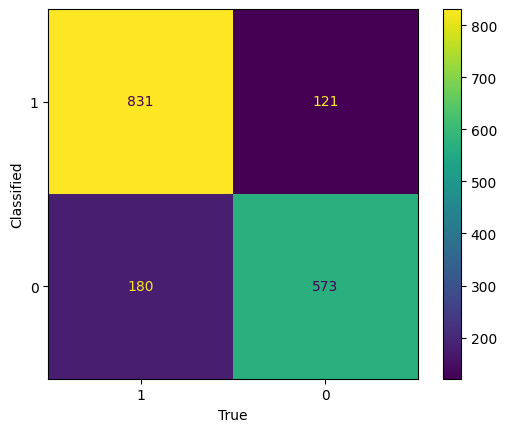

,Sensitividade,Especificidade,Acurácia
0,0.821958,0.825648,0.82346


In [30]:
df_impacto_bin_dummies['phat'] = step_modelo_efeito.predict()

# Matriz de confusão para cutoff = 0.6
matriz_confusao(observado= df_impacto_bin_dummies['Affects_Academic_Performance'],
                predicts= df_impacto_bin_dummies['phat'],
                cutoff=0.60)

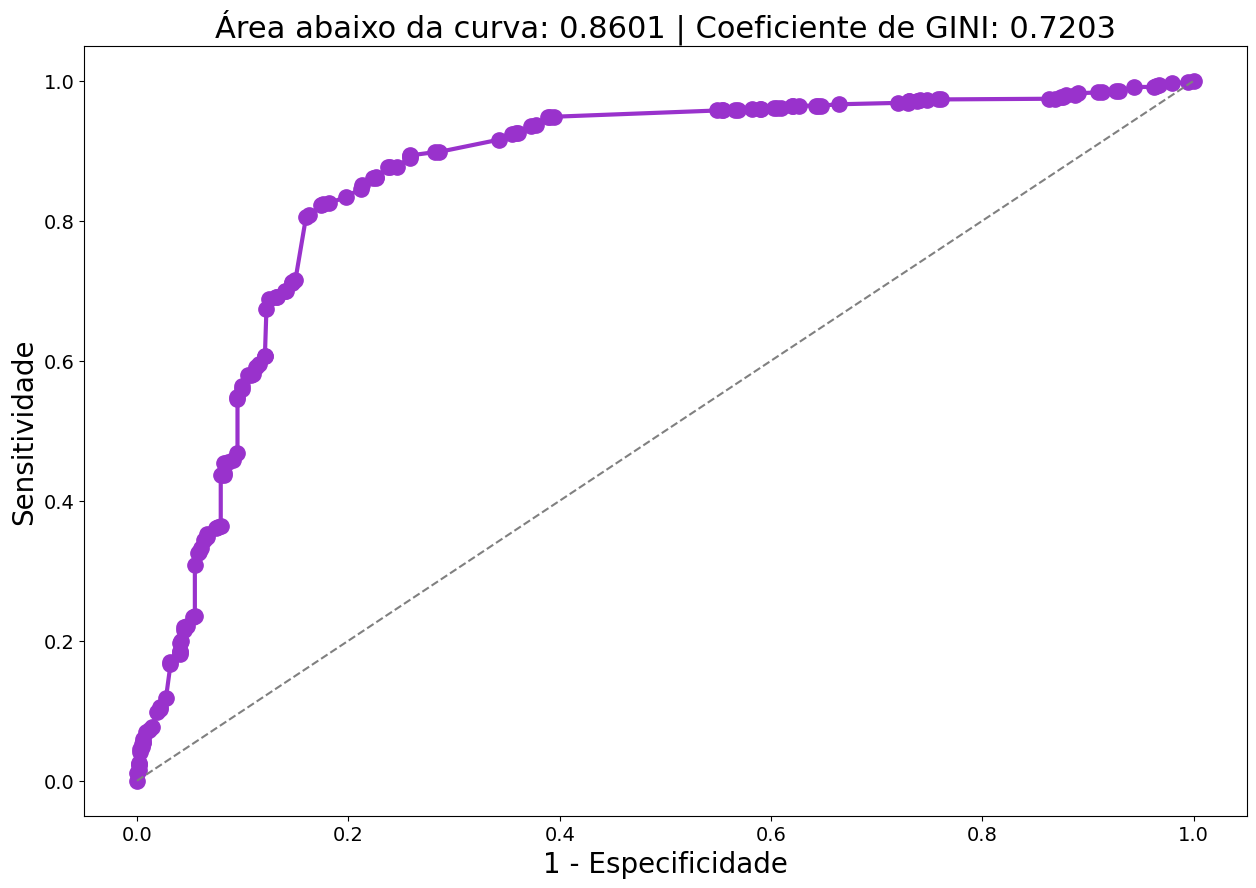

In [31]:
from sklearn.metrics import roc_curve, auc

# Função 'roc_curve' do pacote 'metrics' do sklearn

fpr, tpr, thresholds =roc_curve(df_impacto_bin_dummies['Affects_Academic_Performance'],
                                df_impacto_bin_dummies['phat'])
roc_auc = auc(fpr, tpr)

# Cálculo do coeficiente de GINI
gini = (roc_auc - 0.5)/(0.5)

# Plotando a curva ROC
plt.figure(figsize=(15,10))
plt.plot(fpr, tpr, marker='o', color='darkorchid', markersize=11, linewidth=3)
plt.plot(fpr, fpr, color='gray', linestyle='dashed')
plt.title('Área abaixo da curva: %g' % round(roc_auc, 4) +
          ' | Coeficiente de GINI: %g' % round(gini, 4), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensitividade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()
